# OncoLab AI — Notebook de Modélisation Longitudinale
## Jeu de données : Longitudinal (avec historique patient)

**Prédiction de 5 complications binaires** à partir du bilan biologique actuel + historique des 1–2 cycles précédents.

**Auteur et ML Engineer :** Zeroual Dhia Eddine · Projet de Fin d'Études en Pharmacie
**Encadrant clinique :** Nadia Kerraouch


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

from pathlib import Path
ROOT = Path('..') if Path('../data').exists() else Path('.')
df = pd.read_csv(ROOT / 'data' / 'dataset_longitudinal.csv')

TARGETS = [
    'target_anemia', 'target_neutropenia', 'target_thrombocytopenia',
    'target_renal_toxicity', 'target_hepatic_toxicity',
]
BIO        = ['hb', 'neut', 'plq', 'uree', 'creat', 'asat', 'alat', 'bil']
BIO_LAG1   = ['hb_t1', 'neut_t1', 'plq_t1', 'creat_t1']
BIO_LAG2   = ['hb_t2', 'neut_t2', 'plq_t2', 'creat_t2']
DELTA      = ['delta_hb', 'delta_neut', 'delta_plq']
TRENDS     = ['trend_neut_3cycles', 'drop_rate_plq', 'variability_neut']
LAG_T1     = ['anemia_t1', 'neutropenia_t1', 'thrombocytopenia_t1',
              'renal_toxicity_t1', 'hepatic_toxicity_t1']
LAG_T2     = ['anemia_t2', 'neutropenia_t2', 'thrombocytopenia_t2',
              'renal_toxicity_t2', 'hepatic_toxicity_t2']
DOSE       = ['dose_oxali', 'dose_5fu_bolus', 'dose_5fu_cont', 'dose_af']

print(f'Shape: {df.shape}')
print(f'Patients: {df["patient_id"].nunique()}')
df.head(3)

Shape: (704, 59)
Patients: 108


,patient_id,age,sex_M,bmi,etat,hta,diabetes,renal_disease,hepatic_disease,comorbidity_count,...,delta_neut,delta_plq,trend_neut_3cycles,drop_rate_plq,variability_neut,target_anemia,target_neutropenia,target_thrombocytopenia,target_renal_toxicity,target_hepatic_toxicity
0,P1,50,1,25.1,Surpoids,1,1,0,0,2,...,-5120.0,-63000.0,6891.000000,-0.229947,3151.311314,1,0,0,0,0
1,P1,50,1,25.1,Surpoids,1,1,0,0,2,...,-100.0,-136000.0,4943.333333,-0.566952,2985.319637,1,0,0,0,0
2,P1,50,1,25.1,Surpoids,1,1,0,0,2,...,-350.0,-9000.0,3086.666667,-0.503472,236.290781,1,0,1,0,0


---
## 1. Vue d'ensemble


In [ ]:
df.dtypes.to_frame('dtype').assign(
    non_null=df.notna().sum(),
    null=df.isna().sum(),
    null_pct=(df.isna().mean() * 100).round(1)
).sort_values('null_pct', ascending=False)

,dtype,non_null,null,null_pct
T_stage,float64,703,1,0.1
N_stage,float64,703,1,0.1
patient_id,object,704,0,0.0
bmi,float64,704,0,0.0
etat,object,704,0,0.0
hta,int64,704,0,0.0
diabetes,int64,704,0,0.0
renal_disease,int64,704,0,0.0
hepatic_disease,int64,704,0,0.0
age,int64,704,0,0.0


In [33]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
age,704.0,57.58,11.62,26.00,49.00,59.00,66.00,83.00
sex_M,704.0,0.71,0.46,0.00,0.00,1.00,1.00,1.00
bmi,704.0,23.66,3.99,15.90,20.30,23.20,26.70,35.70
hta,704.0,0.54,0.50,0.00,0.00,1.00,1.00,1.00
diabetes,704.0,0.56,0.50,0.00,0.00,1.00,1.00,1.00
renal_disease,704.0,0.06,0.23,0.00,0.00,0.00,0.00,1.00
hepatic_disease,704.0,0.05,0.21,0.00,0.00,0.00,0.00,1.00
comorbidity_count,704.0,1.20,0.99,0.00,0.00,1.00,2.00,3.00
T_stage,703.0,2.83,0.62,1.00,3.00,3.00,3.00,4.00
N_stage,703.0,1.30,0.58,0.00,1.00,1.00,2.00,2.00


---
## 2. Valeurs manquantes


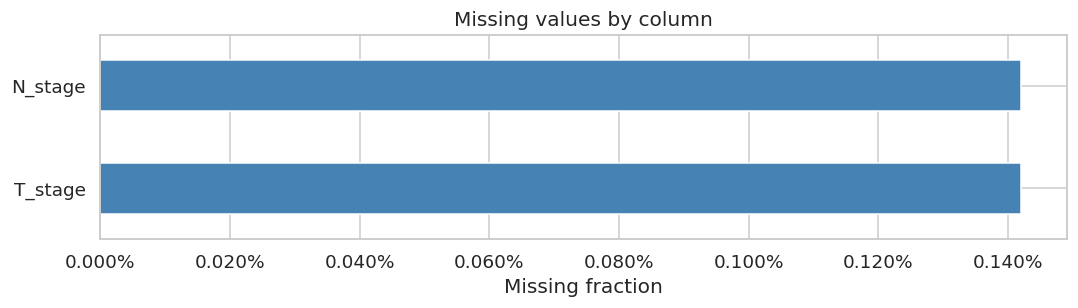

T_stage    0.00142
N_stage    0.00142


In [34]:
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if missing.empty:
    print('No missing values.')
else:
    fig, ax = plt.subplots(figsize=(10, max(3, len(missing) * 0.4)))
    missing.plot.barh(ax=ax, color='steelblue')
    ax.set_xlabel('Missing fraction')
    ax.set_title('Missing values by column')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
    plt.tight_layout(); plt.show()
    print(missing.to_string())

---
## 3. Distribution des cibles et déséquilibre de classes


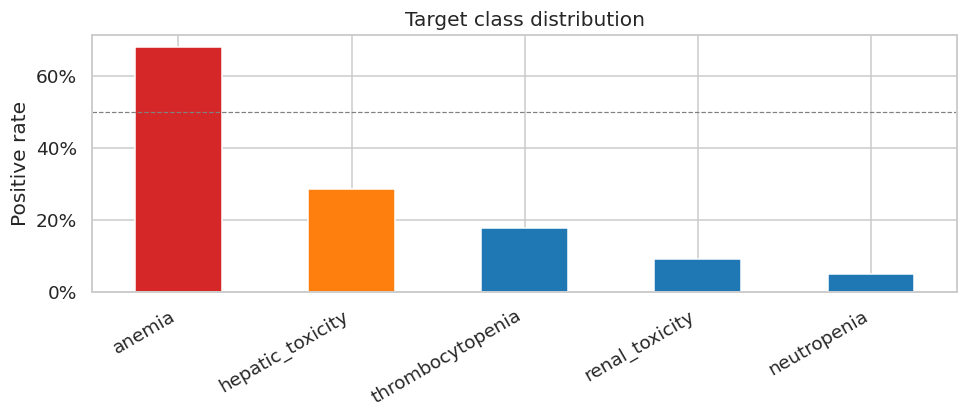

target_anemia              68.0
target_hepatic_toxicity    28.6
target_thrombocytopenia    17.9
target_renal_toxicity       9.1
target_neutropenia          5.1


In [35]:
rates = df[TARGETS].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if r > 0.5 else '#ff7f0e' if r > 0.2 else '#1f77b4' for r in rates]
rates.plot.bar(ax=ax, color=colors, edgecolor='white')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
ax.set_ylabel('Positive rate')
ax.set_title('Target class distribution')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xticklabels([t.replace('target_', '') for t in rates.index], rotation=30, ha='right')
plt.tight_layout(); plt.show()
print((rates * 100).round(1).to_string())

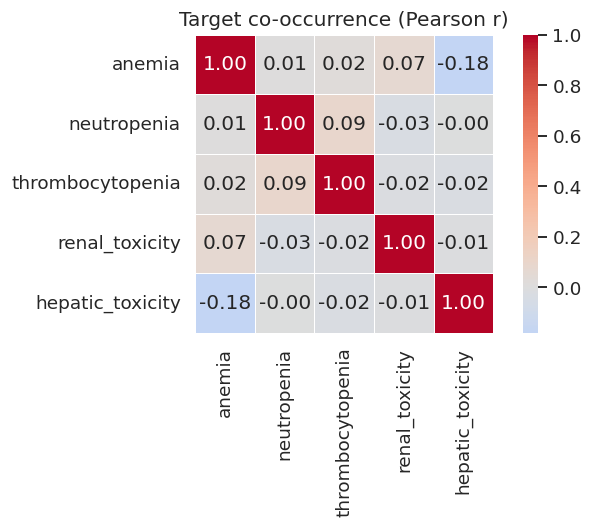

In [36]:
co = df[TARGETS].rename(columns=lambda c: c.replace('target_', '')).corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(co, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Target co-occurrence (Pearson r)')
plt.tight_layout(); plt.show()

---
## 4. Distribution des variables


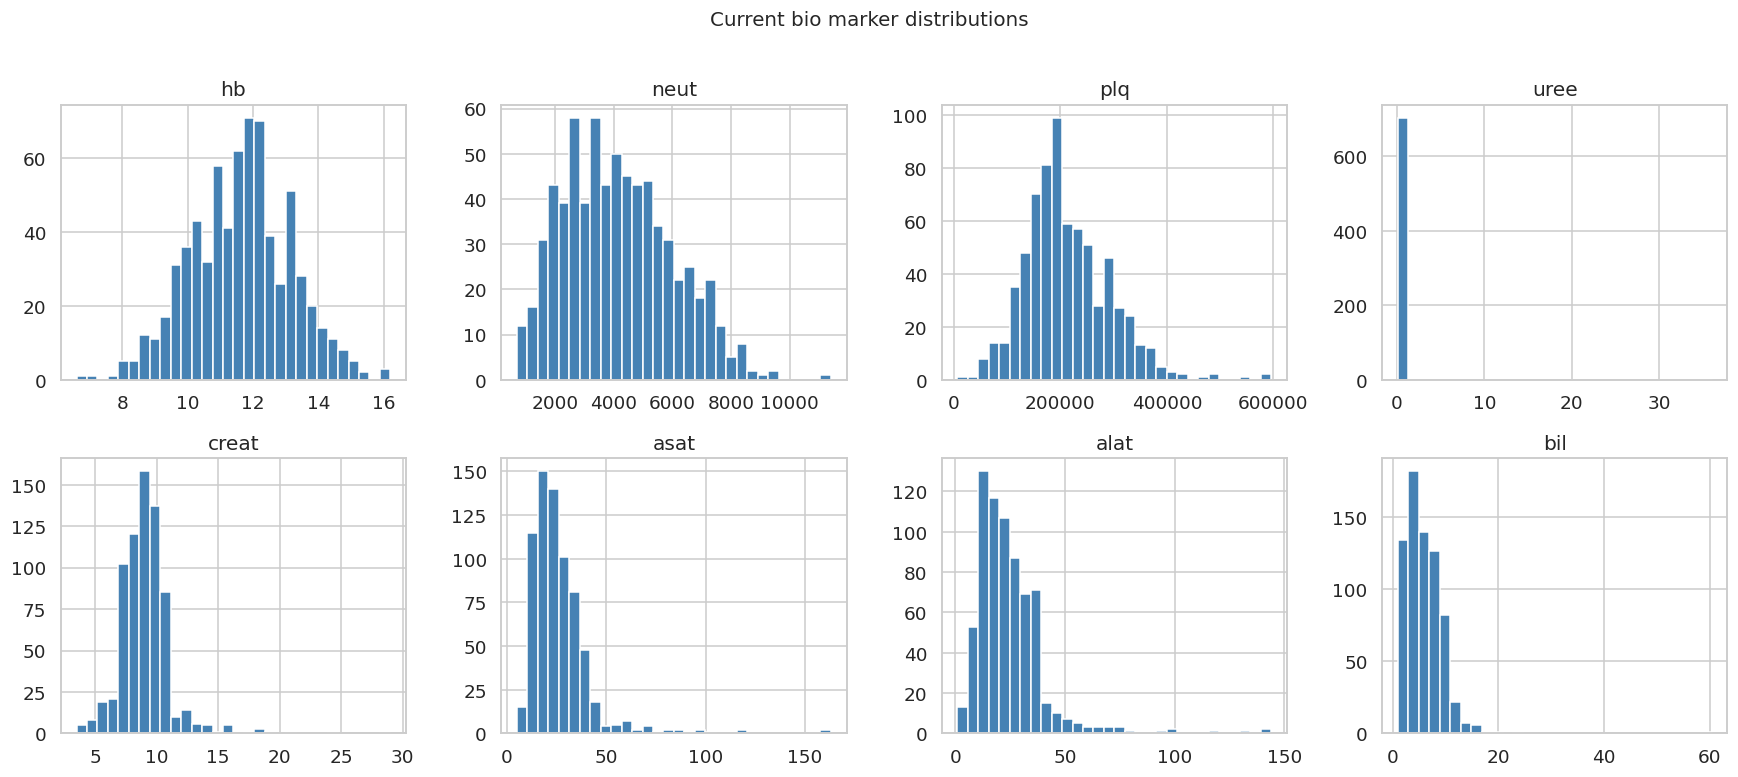

In [37]:
# Current bio markers
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, BIO):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', lw=0.4)
    ax.set_title(col)
plt.suptitle('Current bio marker distributions', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

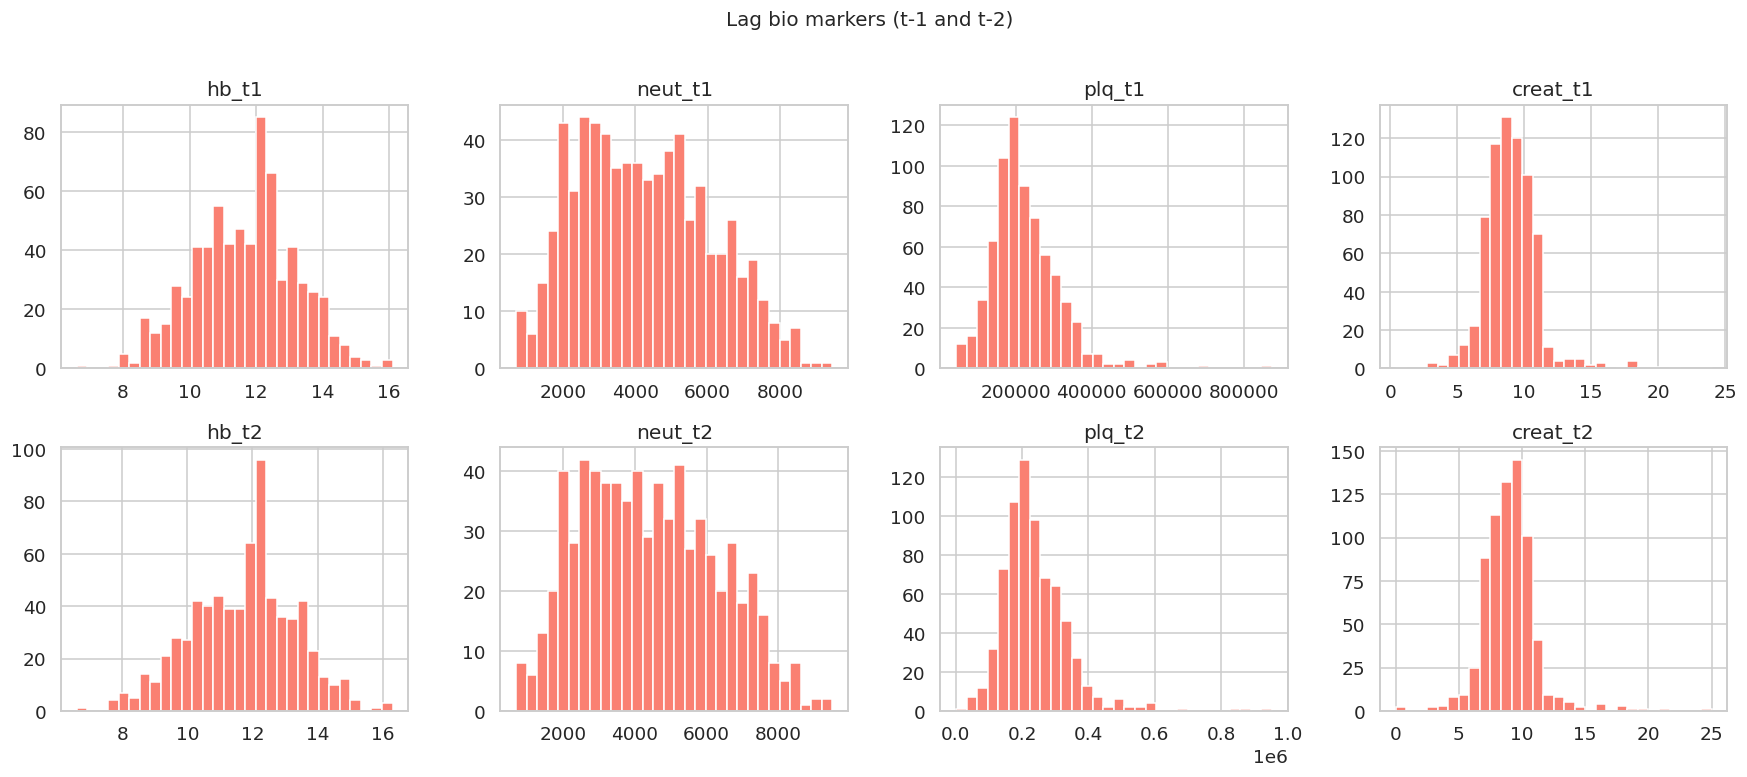

In [38]:
# Lag bio markers (t-1 and t-2) — key = hb, neut, plq, creat
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, BIO_LAG1 + BIO_LAG2):
    ax.hist(df[col].dropna(), bins=30, color='salmon', edgecolor='white', lw=0.4)
    ax.set_title(col)
plt.suptitle('Lag bio markers (t-1 and t-2)', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

---
## 5. Analyse des variables longitudinales

Les variables delta capturent le changement de t-1 à t. Les variables de tendance / variabilité résument les dynamiques sur 3 cycles.


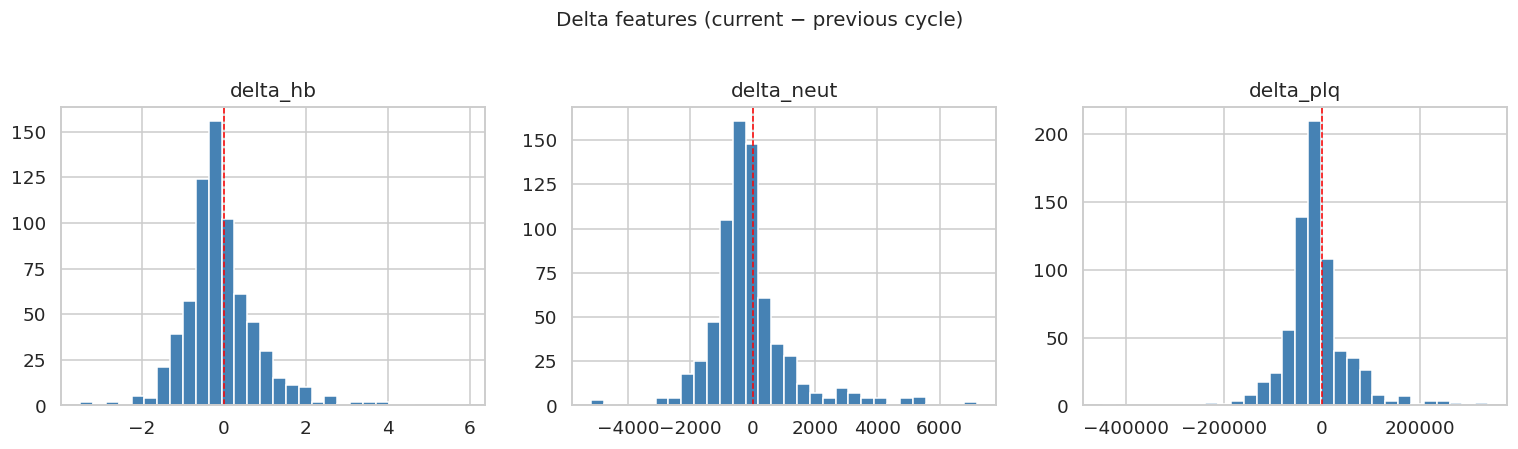

In [40]:
# Delta features: change from previous cycle
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, DELTA):
    ax.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', lw=0.4)
    ax.axvline(0, color='red', linewidth=1, linestyle='--')
    ax.set_title(col)
plt.suptitle('Delta features (current − previous cycle)', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

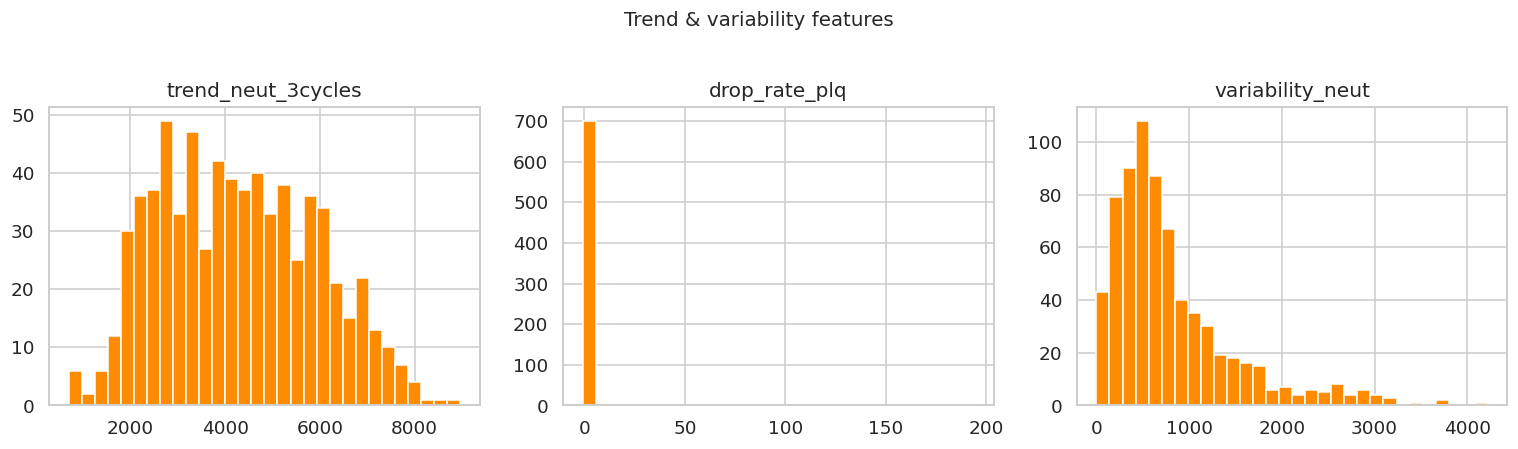

In [41]:
# Trend and variability features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, TRENDS):
    ax.hist(df[col].dropna(), bins=30, color='darkorange', edgecolor='white', lw=0.4)
    ax.set_title(col)
plt.suptitle('Trend & variability features', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

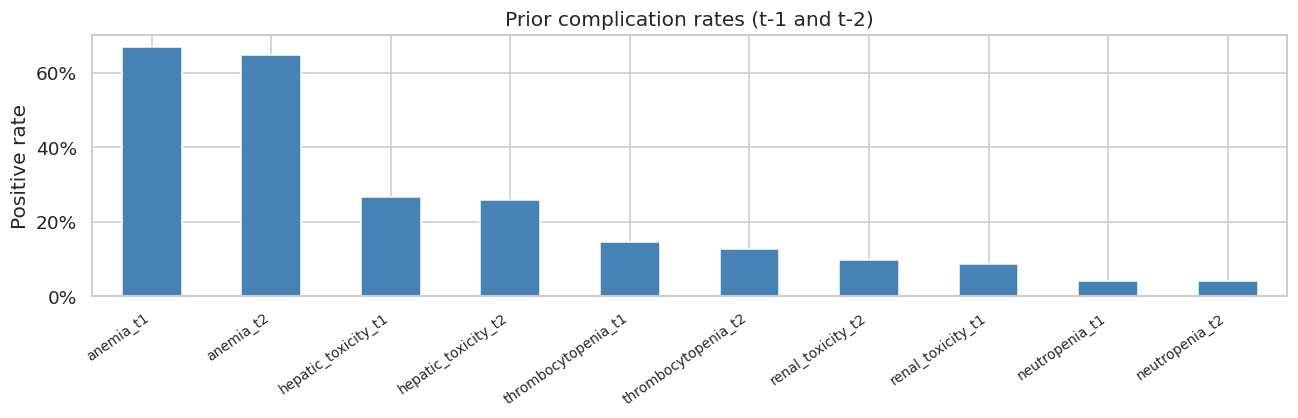

anemia_t1              66.9
anemia_t2              64.9
hepatic_toxicity_t1    26.6
hepatic_toxicity_t2    26.0
thrombocytopenia_t1    14.6
thrombocytopenia_t2    12.6
renal_toxicity_t2       9.8
renal_toxicity_t1       8.7
neutropenia_t1          4.1
neutropenia_t2          4.1


In [42]:
# Prior complication status (t-1 and t-2)
prior_rates = df[LAG_T1 + LAG_T2].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(12, 4))
prior_rates.plot.bar(ax=ax, color='steelblue', edgecolor='white')
ax.set_ylabel('Positive rate')
ax.set_title('Prior complication rates (t-1 and t-2)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set_xticklabels(prior_rates.index, rotation=35, ha='right', fontsize=9)
plt.tight_layout(); plt.show()
print((prior_rates * 100).round(1).to_string())

In [43]:
# How much does prior complication predict the next one?
print('Correlation between prior status and same-cycle target:')
pairs = [
    ('anemia_t1',           'target_anemia'),
    ('neutropenia_t1',      'target_neutropenia'),
    ('thrombocytopenia_t1', 'target_thrombocytopenia'),
    ('renal_toxicity_t1',   'target_renal_toxicity'),
    ('hepatic_toxicity_t1', 'target_hepatic_toxicity'),
]
for lag, tgt in pairs:
    r = df[lag].corr(df[tgt])
    print(f'  {lag:30s}  →  {tgt:35s}  r = {r:.3f}')

Correlation between prior status and same-cycle target:
  anemia_t1                       →  target_anemia                        r = 0.709
  neutropenia_t1                  →  target_neutropenia                   r = 0.309
  thrombocytopenia_t1             →  target_thrombocytopenia              r = 0.425
  renal_toxicity_t1               →  target_renal_toxicity                r = 0.359
  hepatic_toxicity_t1             →  target_hepatic_toxicity              r = 0.424


---
## 6. Détection des valeurs aberrantes


In [44]:
# Unit check: plq and neut (current + lags)
for col in ['plq', 'plq_t1', 'plq_t2']:
    med = df[col].median()
    note = '  ← divide by 1000 (cells/µL → G/L)' if med > 1000 else ''
    print(f'{col:12s}  median = {med:>12.1f}{note}')

print()
for col in ['neut', 'neut_t1', 'neut_t2']:
    med = df[col].median()
    note = '  ← divide by 1000 (cells/µL → G/L)' if med > 30 else ''
    print(f'{col:12s}  median = {med:>12.1f}{note}')

plq           median =     199208.5  ← divide by 1000 (cells/µL → G/L)
plq_t1        median =     209459.0  ← divide by 1000 (cells/µL → G/L)
plq_t2        median =     220195.0  ← divide by 1000 (cells/µL → G/L)

neut          median =       4000.0  ← divide by 1000 (cells/µL → G/L)
neut_t1       median =       4113.0  ← divide by 1000 (cells/µL → G/L)
neut_t2       median =       4300.0  ← divide by 1000 (cells/µL → G/L)


In [45]:
# Check delta_plq, delta_neut, trend_neut_3cycles, variability_neut for scale
print('Delta and trend feature ranges (pre-unit-correction):')
for col in ['delta_neut', 'delta_plq', 'trend_neut_3cycles', 'variability_neut']:
    print(f'  {col:25s}  min={df[col].min():>12.1f}  max={df[col].max():>12.1f}  median={df[col].median():>12.1f}')

print()
print('drop_rate_plq (ratio — no unit conversion needed):')
print(f'  min={df["drop_rate_plq"].min():.3f}  max={df["drop_rate_plq"].max():.3f}  median={df["drop_rate_plq"].median():.3f}')

Delta and trend feature ranges (pre-unit-correction):
  delta_neut                 min=     -5180.0  max=      7200.0  median=      -291.0
  delta_plq                  min=   -447220.0  max=    339434.0  median=    -14799.5
  trend_neut_3cycles         min=       700.0  max=      8960.0  median=      4198.3
  variability_neut           min=         0.0  max=      4222.0  median=       612.4

drop_rate_plq (ratio — no unit conversion needed):
  min=-0.927  max=193.894  median=-0.130


In [46]:
# uree outlier check
print('uree values > 1:')
print(df[df['uree'] > 1][['patient_id', 'cycle_num', 'uree']])

uree values > 1:
    patient_id  cycle_num   uree
83         P17          2   1.02
112        P21          9  36.00


In [47]:
# creat clinical range (>13 mg/dL suspicious)
creat_out = df[df['creat'] > 13][['patient_id', 'cycle_num', 'creat']]
print(f'{len(creat_out)} creat values above 13 mg/dL (likely µmol/L entries):')
print(creat_out.head(5))

20 creat values above 13 mg/dL (likely µmol/L entries):
    patient_id  cycle_num  creat
165         P3          3  17.49
175        P31          2  21.00
176        P31          3  24.00
177        P31          4  29.00
197        P34          9  13.10


---
## 7. Matrice de corrélation


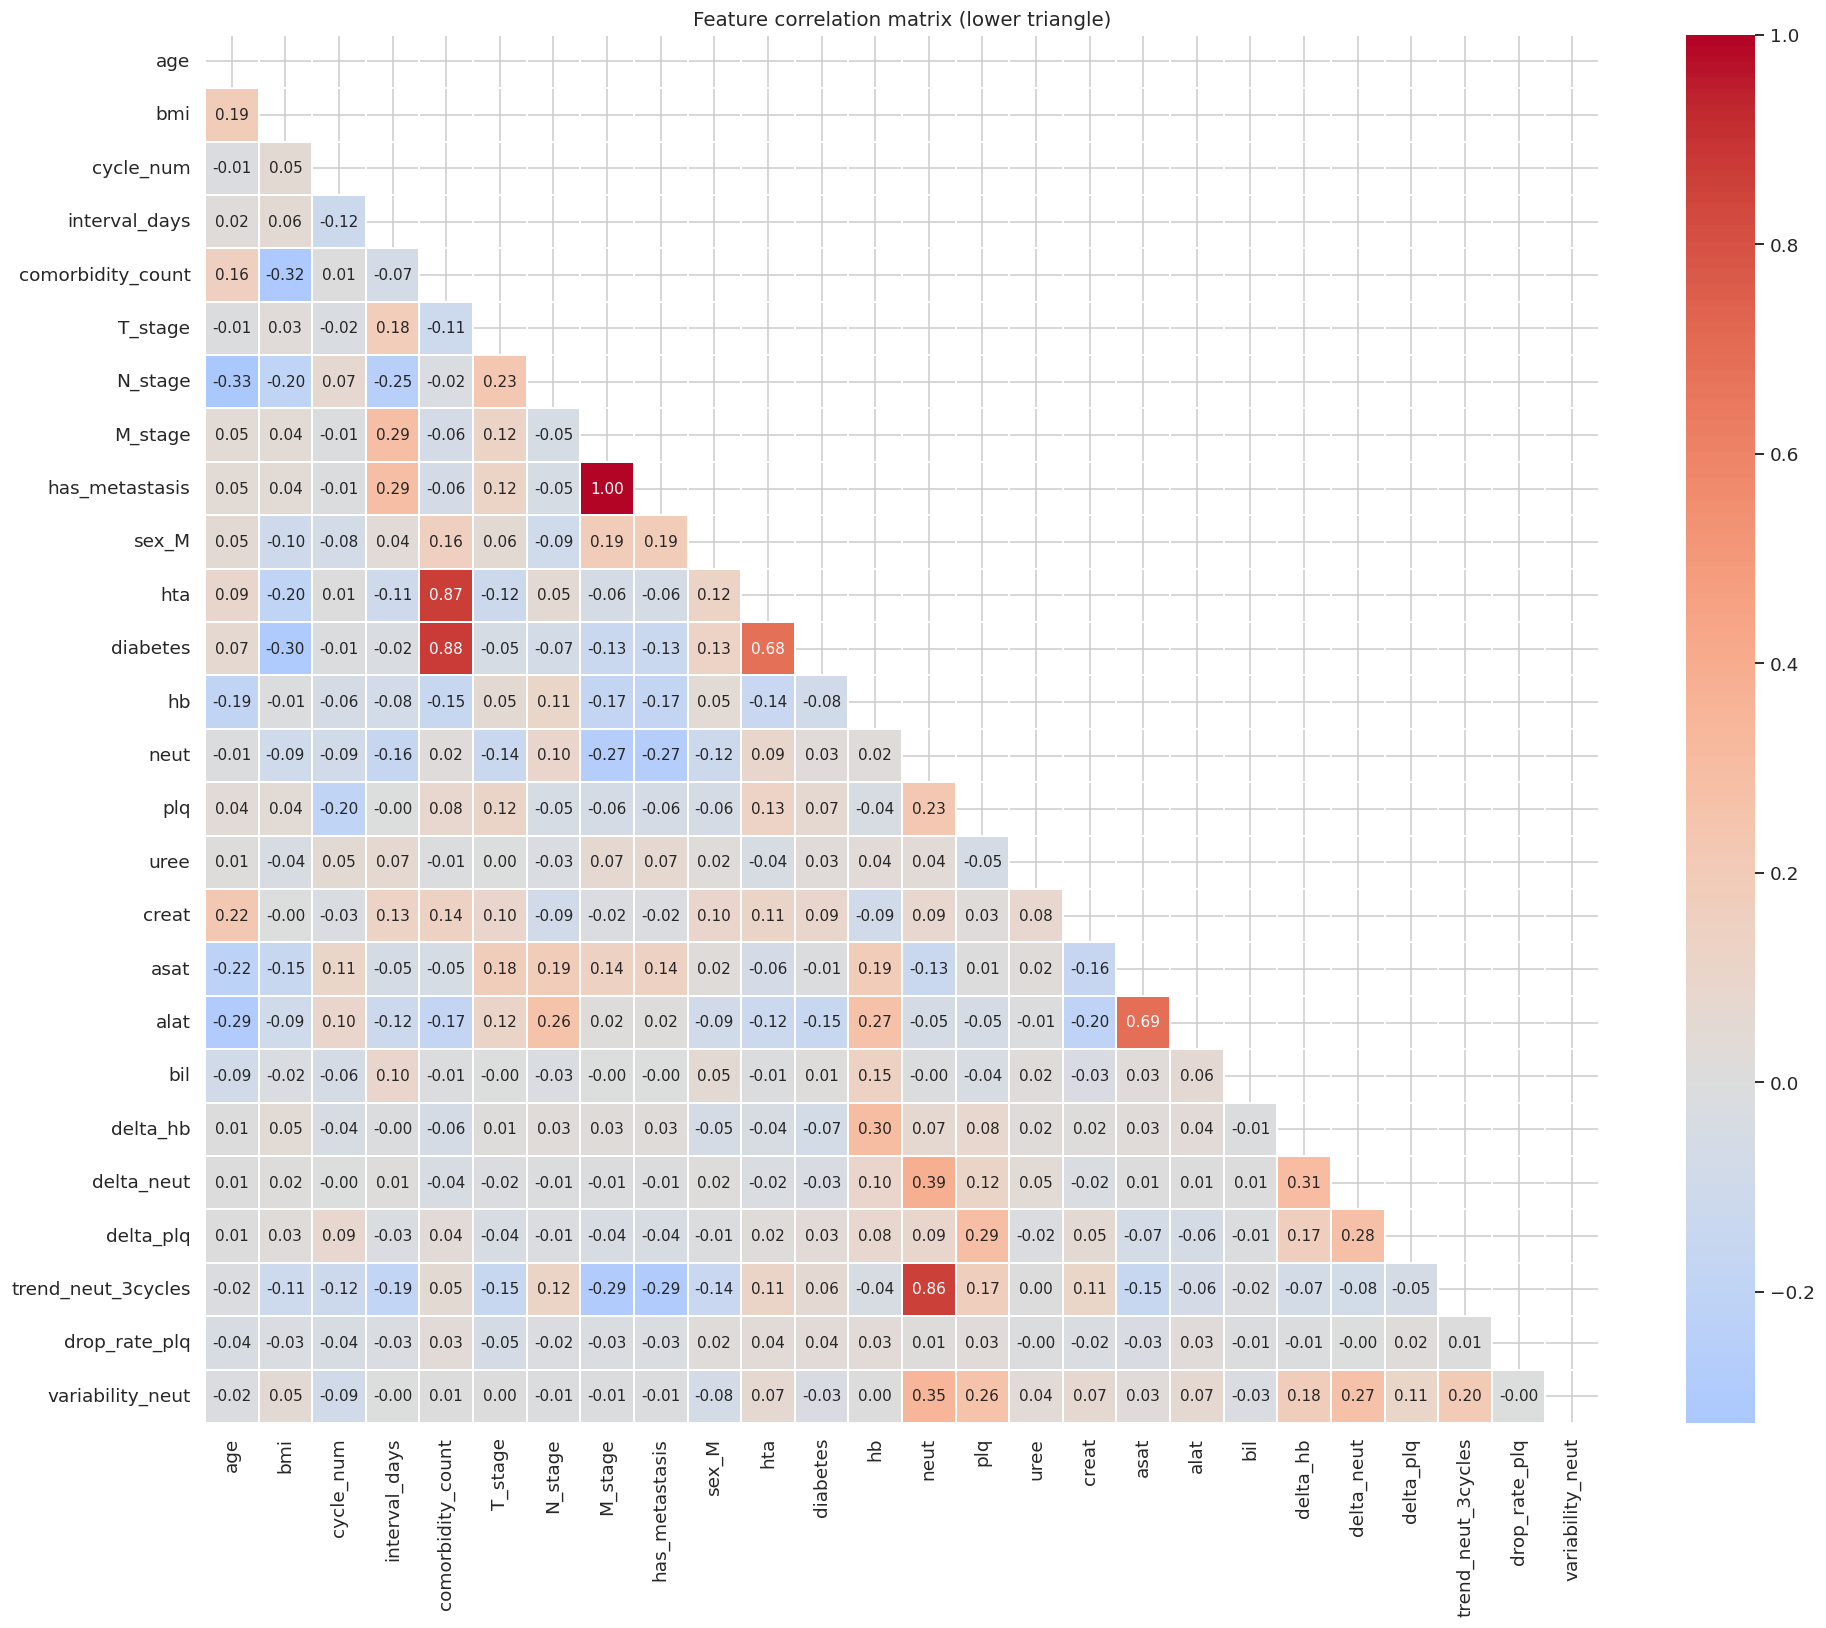

In [49]:
demo_cols = ['age', 'bmi', 'cycle_num', 'interval_days', 'comorbidity_count',
             'T_stage', 'N_stage', 'M_stage', 'has_metastasis', 'sex_M',
             'hta', 'diabetes']
num_cols = [c for c in demo_cols + BIO + DELTA + TRENDS if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, fmt='.2f',
            annot=True, linewidths=0.3, ax=ax, annot_kws={'size': 10})
ax.set_title('Feature correlation matrix (lower triangle)', fontsize=13)
plt.tight_layout(); plt.show()

In [50]:
# Top correlates per target (including longitudinal features)
all_num = [c for c in num_cols + BIO_LAG1 + BIO_LAG2 + LAG_T1 if c in df.columns]
target_corr = df[all_num + TARGETS].corr()
for t in TARGETS:
    top = target_corr[t].drop(TARGETS, errors='ignore').abs().sort_values(ascending=False).head(10)
    print(f'\n--- {t} (top 10 correlates) ---')
    print(target_corr[t][top.index].round(3).to_string())


--- target_anemia (top 10 correlates) ---
anemia_t1              0.709
hb                    -0.670
hb_t1                 -0.522
hb_t2                 -0.445
sex_M                  0.286
delta_hb              -0.232
alat                  -0.223
age                    0.159
comorbidity_count      0.143
hepatic_toxicity_t1   -0.140

--- target_neutropenia (top 10 correlates) ---
neutropenia_t1        0.309
trend_neut_3cycles   -0.275
neut_t1              -0.249
neut                 -0.243
neut_t2              -0.240
T_stage               0.198
bmi                   0.135
hta                  -0.133
interval_days         0.099
variability_neut      0.094

--- target_thrombocytopenia (top 10 correlates) ---
plq                   -0.582
thrombocytopenia_t1    0.425
plq_t1                -0.394
plq_t2                -0.330
cycle_num              0.210
delta_plq             -0.155
comorbidity_count     -0.153
hta                   -0.152
diabetes              -0.144
variability_neut      -0.

---
## 8. Résumé de la cohorte


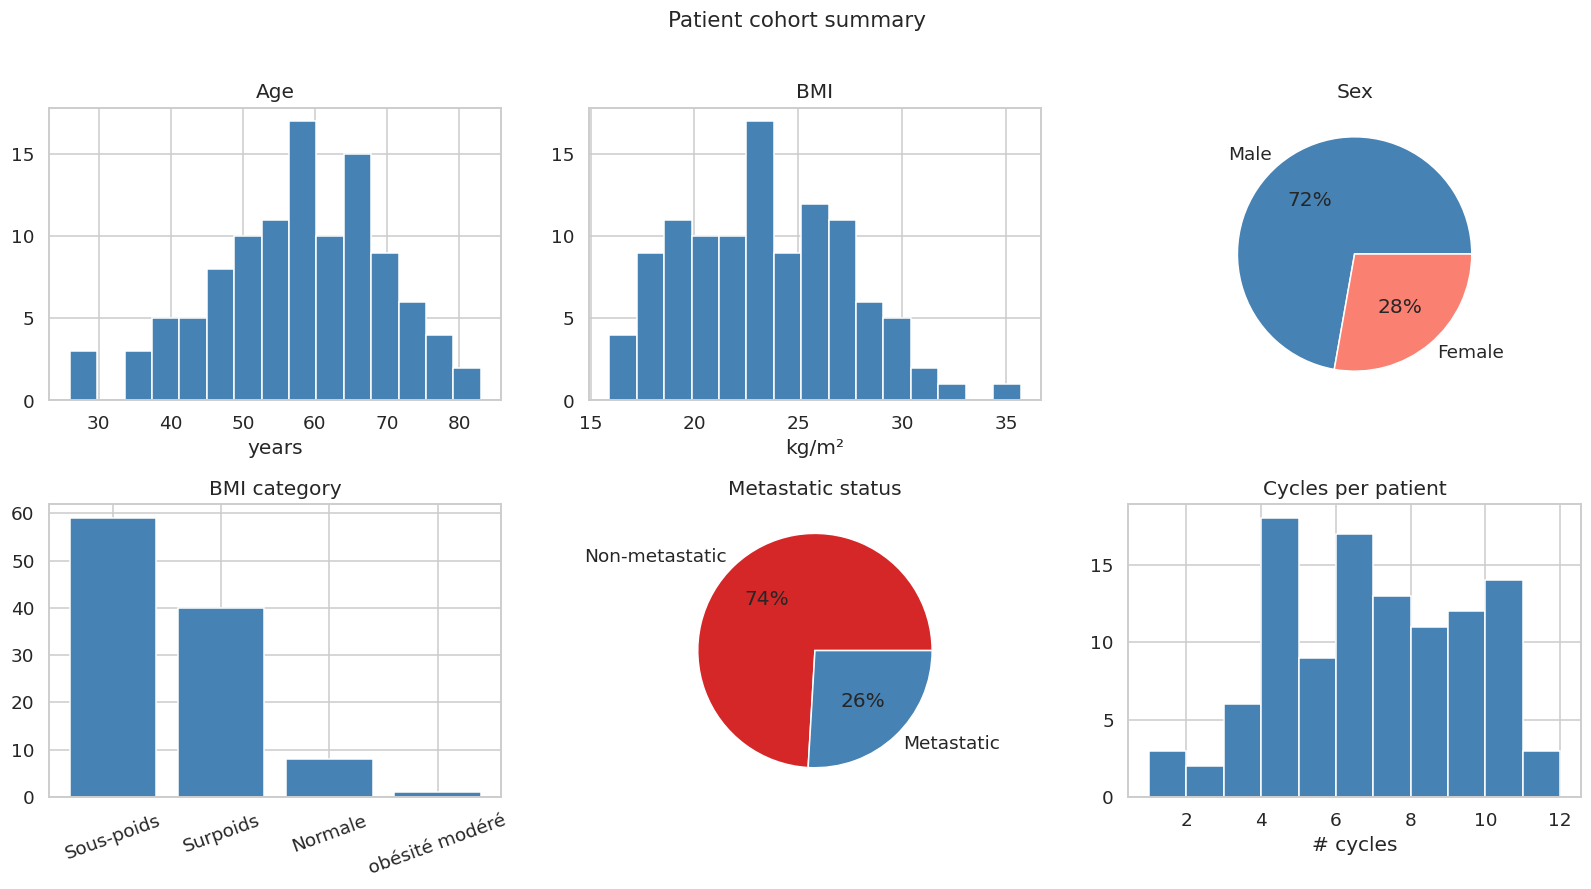

Age:        mean=57.6  std=12.1
BMI:        mean=23.5  std=4.0
Sex:        {'Male': 78, 'Female': 30}
Metastatic: {'Non-metastatic': 80, 'Metastatic': 28}
Cycles:     median=6  min=1  max=11


In [51]:
patients = df.groupby('patient_id').first().reset_index()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0,0].hist(patients['age'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0,0].set_title('Age'); axes[0,0].set_xlabel('years')

axes[0,1].hist(patients['bmi'].dropna(), bins=15, color='steelblue', edgecolor='white')
axes[0,1].set_title('BMI'); axes[0,1].set_xlabel('kg/m²')

sex_c = patients['sex_M'].value_counts().rename({1:'Male', 0:'Female'})
axes[0,2].pie(sex_c, labels=sex_c.index, autopct='%1.0f%%',
              colors=['steelblue','salmon'])
axes[0,2].set_title('Sex')

etat_c = patients['etat'].value_counts()
axes[1,0].bar(etat_c.index, etat_c.values, color='steelblue', edgecolor='white')
axes[1,0].set_title('BMI category'); axes[1,0].tick_params(axis='x', rotation=20)

m_c = patients['has_metastasis'].value_counts().rename({1:'Metastatic', 0:'Non-metastatic'})
axes[1,1].pie(m_c, labels=m_c.index, autopct='%1.0f%%', colors=['#d62728','steelblue'])
axes[1,1].set_title('Metastatic status')

n_cycles = df.groupby('patient_id')['cycle_num'].count()
axes[1,2].hist(n_cycles, bins=range(1, n_cycles.max()+2), color='steelblue', edgecolor='white')
axes[1,2].set_title('Cycles per patient'); axes[1,2].set_xlabel('# cycles')

plt.suptitle('Patient cohort summary', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

print(f"Age:        mean={patients['age'].mean():.1f}  std={patients['age'].std():.1f}")
print(f"BMI:        mean={patients['bmi'].mean():.1f}  std={patients['bmi'].std():.1f}")
print(f"Sex:        {sex_c.to_dict()}")
print(f"Metastatic: {m_c.to_dict()}")
print(f"Cycles:     median={n_cycles.median():.0f}  min={n_cycles.min()}  max={n_cycles.max()}")

---
## Résumé des observations de l'AED

| Sujet | Observation |
|---|---|
| **Valeurs manquantes** | Seuls `T_stage` / `N_stage` ont des NaN (2 lignes) — les arbres les gèrent nativement |
| **Déséquilibre de classes** | La neutropénie (5,1 %) et la toxicité rénale (9,1 %) sont des événements rares |
| **Distributions** | Les biomarqueurs sont approximativement normaux avec quelques valeurs extrêmes (plaquettes, bilirubine) |
| **Corrélations** | Les complications antérieures (`*_t1`) et les biomarqueurs décalés sont les plus corrélés aux cibles |
| **Valeurs aberrantes** | ~20 valeurs de créatinine suspectes conservées en attente de confirmation clinique |


---
## 9. Prétraitement

**Décisions basées sur les observations de l'AED :**

| Colonne | Action | Raison |
|---|---|---|
| `patient_id` | Supprimé | Identifiant, pas une variable — utilisé uniquement pour le regroupement |
| `etat` | Encodé en ordinal (0/1/2) | 3 catégories ordonnées |
| `cancer_type` | Encodé one-hot | Catégorielle nominale |
| `treatment_intent` | Encodé binaire | 2 catégories |
| Toutes les variables numériques | StandardScaler **dans chaque pli** | Éviter la fuite de mise à l'échelle |


In [52]:
df_clean = df.copy()

# Current bio markers
if df_clean['plq'].median() > 1000:
    df_clean['plq'] = df_clean['plq'] / 1000
    print('plq ÷ 1000')
if df_clean['neut'].median() > 30:
    df_clean['neut'] = df_clean['neut'] / 1000
    print('neut ÷ 1000')

# Lag bio markers
for col in ['plq_t1', 'plq_t2']:
    if df_clean[col].median() > 1000:
        df_clean[col] = df_clean[col] / 1000
        print(f'{col} ÷ 1000')

for col in ['neut_t1', 'neut_t2']:
    if df_clean[col].median() > 30:
        df_clean[col] = df_clean[col] / 1000
        print(f'{col} ÷ 1000')

# Derived features: delta and trend (also in cells/µL scale)
for col in ['delta_plq', 'delta_neut', 'trend_neut_3cycles', 'variability_neut']:
    df_clean[col] = df_clean[col] / 1000
    print(f'{col} ÷ 1000')

print('Unit corrections done.')

plq ÷ 1000
neut ÷ 1000
plq_t1 ÷ 1000
plq_t2 ÷ 1000
neut_t1 ÷ 1000
neut_t2 ÷ 1000
delta_plq ÷ 1000
delta_neut ÷ 1000
trend_neut_3cycles ÷ 1000
variability_neut ÷ 1000
Unit corrections done.


In [53]:
# Fix uree outlier
print('uree > 1 before fix:')
print(df_clean[df_clean['uree'] > 1][['patient_id', 'cycle_num', 'uree']])
df_clean.loc[df_clean['uree'] == 36, 'uree'] = 0.36
print('uree > 1 after fix:')
print(df_clean[df_clean['uree'] > 1][['patient_id', 'cycle_num', 'uree']])

uree > 1 before fix:
    patient_id  cycle_num   uree
83         P17          2   1.02
112        P21          9  36.00
uree > 1 after fix:
   patient_id  cycle_num  uree
83        P17          2  1.02


In [54]:
# Categorical encoding
CAT_COLS = ['treatment_intent']
df_encoded = pd.get_dummies(df_clean, columns=CAT_COLS, drop_first=False)

ETAT_ORDINAL = {'Sous-poids': 0, 'Normale': 1, 'Surpoids': 2}
df_encoded['etat'] = df_clean['etat'].map(ETAT_ORDINAL)

DROP_COLS = [c for c in ['cancer_type'] if c in df_encoded.columns]
df_encoded = df_encoded.drop(columns=DROP_COLS, errors='ignore')

print(f'Shape after encoding: {df_encoded.shape}')
print(df_encoded.columns.tolist())

Shape after encoding: (704, 59)
['patient_id', 'age', 'sex_M', 'bmi', 'etat', 'hta', 'diabetes', 'renal_disease', 'hepatic_disease', 'comorbidity_count', 'T_stage', 'N_stage', 'M_stage', 'has_metastasis', 'cycle_num', 'interval_days', 'dose_oxali', 'dose_5fu_bolus', 'dose_5fu_cont', 'dose_af', 'hb', 'neut', 'plq', 'uree', 'creat', 'asat', 'alat', 'bil', 'hb_t1', 'neut_t1', 'plq_t1', 'creat_t1', 'hb_t2', 'neut_t2', 'plq_t2', 'creat_t2', 'anemia_t1', 'neutropenia_t1', 'thrombocytopenia_t1', 'renal_toxicity_t1', 'hepatic_toxicity_t1', 'anemia_t2', 'neutropenia_t2', 'thrombocytopenia_t2', 'renal_toxicity_t2', 'hepatic_toxicity_t2', 'delta_hb', 'delta_neut', 'delta_plq', 'trend_neut_3cycles', 'drop_rate_plq', 'variability_neut', 'target_anemia', 'target_neutropenia', 'target_thrombocytopenia', 'target_renal_toxicity', 'target_hepatic_toxicity', 'treatment_intent_Adj', 'treatment_intent_Neoadj']


In [55]:
# Feature matrix (X) and targets (y)
groups = df_encoded['patient_id'].values

X_df  = df_encoded.drop(columns=TARGETS + ['patient_id'], errors='ignore')
y_all = df_encoded[TARGETS].astype(int)
X_arr = X_df.values  # unscaled — scaling happens inside each CV fold

print(f'X shape: {X_df.shape}')
print(f'y shape: {y_all.shape}')
print(f'Groups (patients): {len(set(groups))}')
print(f'\nTarget counts:')
print(y_all.sum().to_string())

X shape: (704, 53)
y shape: (704, 5)
Groups (patients): 108

Target counts:
target_anemia              479
target_neutropenia          36
target_thrombocytopenia    126
target_renal_toxicity       64
target_hepatic_toxicity    201


---
## 10. Entraînement

Cinq classifieurs binaires indépendants — un par cible de complication.

### Pipeline
1. Découpage patient-level 80/20 (`GroupShuffleSplit`) → ensemble d'entraînement et ensemble de test isolé
2. Validation croisée `GroupKFold` à 5 plis sur l'ensemble d'entraînement (par identifiant patient)
3. Mise à l'échelle `StandardScaler` ajustée **uniquement** sur les données d'entraînement du pli
4. Ensemble : vote souple des 3 meilleurs modèles par AUC-ROC CV moyenne


In [56]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("XGBoost not installed — pip install xgboost")

try:
    from lightgbm import LGBMClassifier
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("LightGBM not installed — pip install lightgbm")

---
### Fonction d'aide — Validation croisée — `evaluate_model`

Exécute une validation croisée `GroupKFold` à 5 plis sur l'**ensemble d'entraînement** (86 patients) pour un modèle
et une cible donnés. Renvoie les métriques moyennes sur les plis.


In [57]:
def evaluate_model(model, X, y, groups, n_splits=5):
    """GroupKFold CV with per-fold scaling; scaler is fit on train fold only."""
    gkf = GroupKFold(n_splits=n_splits)
    aucs, f1s, recs, specs, ppvs = [], [], [], [], []

    for train_idx, test_idx in gkf.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_te_s = scaler.transform(X_te)

        clf = clone(model)
        clf.fit(X_tr_s, y_tr)
        proba = clf.predict_proba(X_te_s)[:, 1]
        pred  = (proba >= 0.5).astype(int)

        if len(np.unique(y_te)) < 2:
            continue

        tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()
        aucs.append(roc_auc_score(y_te, proba))
        f1s.append(f1_score(y_te, pred, zero_division=0))
        recs.append(recall_score(y_te, pred, zero_division=0))
        specs.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
        ppvs.append(precision_score(y_te, pred, zero_division=0))

    def ms(lst): return (np.mean(lst), np.std(lst))
    return {
        "AUC-ROC":     ms(aucs),
        "Sensitivity": ms(recs),
        "Specificity": ms(specs),
        "PPV":         ms(ppvs),
        "F1":          ms(f1s),
    }

In [58]:
# Patient-level train/test split — hold out 20% of patients as final test set
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_pat_idx, test_pat_idx = next(gss.split(X_arr, groups=groups))

X_train, X_test  = X_arr[train_pat_idx], X_arr[test_pat_idx]
y_train_all      = y_all.iloc[train_pat_idx].reset_index(drop=True)
y_test_all       = y_all.iloc[test_pat_idx].reset_index(drop=True)
groups_train     = groups[train_pat_idx]

print(f'Train: {X_train.shape[0]} rows, {len(set(groups_train))} patients')
print(f'Test:  {X_test.shape[0]} rows, {len(set(groups[test_pat_idx]))} patients')

pos_ratios = {t: y_train_all[t].mean() for t in TARGETS}

results = {}

for target in TARGETS:
    y_tr     = y_train_all[target].values
    short    = target.replace("target_", "")
    pos_rate = pos_ratios[target]

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
    }
    if HAS_XGB:
        spw = (1 - pos_rate) / pos_rate if pos_rate > 0 else 1.0
        models["XGBoost"] = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=42, n_jobs=-1, verbosity=0
        )
    if HAS_LGB:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
        )

    results[target] = {}
    for name, clf in models.items():
        print(f"{short:30s} | {name} ...", end=" ", flush=True)
        metrics = evaluate_model(clf, X_train, y_tr, groups_train)
        results[target][name] = metrics
        auc_m, auc_s = metrics["AUC-ROC"]
        print(f"AUC {auc_m:.3f} ± {auc_s:.3f}")

Train: 563 rows, 86 patients
Test:  141 rows, 22 patients
anemia                         | RandomForest ... AUC 0.969 ± 0.012
anemia                         | ExtraTrees ... AUC 0.964 ± 0.009
anemia                         | XGBoost ... AUC 0.979 ± 0.011
anemia                         | LightGBM ... AUC 0.980 ± 0.013
neutropenia                    | RandomForest ... AUC 0.976 ± 0.036
neutropenia                    | ExtraTrees ... AUC 0.909 ± 0.090
neutropenia                    | XGBoost ... AUC 0.993 ± 0.012
neutropenia                    | LightGBM ... AUC 0.996 ± 0.008
thrombocytopenia               | RandomForest ... AUC 0.995 ± 0.002
thrombocytopenia               | ExtraTrees ... AUC 0.977 ± 0.010
thrombocytopenia               | XGBoost ... AUC 0.997 ± 0.003
thrombocytopenia               | LightGBM ... AUC 0.997 ± 0.002
renal_toxicity                 | RandomForest ... AUC 0.952 ± 0.086
renal_toxicity                 | ExtraTrees ... AUC 0.928 ± 0.089
renal_toxicity           

In [59]:
# CV summary table
rows = []
for target, model_results in results.items():
    short = target.replace("target_", "")
    for model_name, metrics in model_results.items():
        row = {"Target": short, "Model": model_name}
        for metric, (mean, std) in metrics.items():
            row[metric] = f"{mean:.3f} ± {std:.3f}"
        rows.append(row)

summary = pd.DataFrame(rows).set_index(["Target", "Model"])
print(summary.to_string())
summary

                                     AUC-ROC    Sensitivity    Specificity            PPV             F1
Target           Model                                                                                  
anemia           RandomForest  0.969 ± 0.012  0.962 ± 0.019  0.811 ± 0.064  0.911 ± 0.070  0.935 ± 0.043
                 ExtraTrees    0.964 ± 0.009  0.945 ± 0.025  0.734 ± 0.081  0.889 ± 0.054  0.915 ± 0.031
                 XGBoost       0.979 ± 0.011  0.948 ± 0.055  0.912 ± 0.065  0.949 ± 0.046  0.947 ± 0.036
                 LightGBM      0.980 ± 0.013  0.943 ± 0.053  0.905 ± 0.061  0.946 ± 0.044  0.943 ± 0.031
neutropenia      RandomForest  0.976 ± 0.036  0.591 ± 0.229  1.000 ± 0.000  1.000 ± 0.000  0.713 ± 0.208
                 ExtraTrees    0.909 ± 0.090  0.125 ± 0.250  1.000 ± 0.000  0.200 ± 0.400  0.154 ± 0.308
                 XGBoost       0.993 ± 0.012  0.893 ± 0.137  0.994 ± 0.005  0.931 ± 0.057  0.903 ± 0.072
                 LightGBM      0.996 ± 0.008  0.893 ± 0

AUC-ROC    Sensitivity    Specificity  \
Target           Model                                                       
anemia           RandomForest  0.969 ± 0.012  0.962 ± 0.019  0.811 ± 0.064   
                 ExtraTrees    0.964 ± 0.009  0.945 ± 0.025  0.734 ± 0.081   
                 XGBoost       0.979 ± 0.011  0.948 ± 0.055  0.912 ± 0.065   
                 LightGBM      0.980 ± 0.013  0.943 ± 0.053  0.905 ± 0.061   
neutropenia      RandomForest  0.976 ± 0.036  0.591 ± 0.229  1.000 ± 0.000   
                 ExtraTrees    0.909 ± 0.090  0.125 ± 0.250  1.000 ± 0.000   
                 XGBoost       0.993 ± 0.012  0.893 ± 0.137  0.994 ± 0.005   
                 LightGBM      0.996 ± 0.008  0.893 ± 0.137  0.996 ± 0.007   
thrombocytopenia RandomForest  0.995 ± 0.002  0.950 ± 0.072  0.985 ± 0.011   
                 ExtraTrees    0.977 ± 0.010  0.527 ± 0.151  0.989 ± 0.010   
                 XGBoost       0.997 ± 0.003  1.000 ± 0.000  0.985 ± 0.011   
                 LightGBM      0.997 ± 0.002  1.000 ± 0.000  0.985 ± 0.011   
renal_toxicity   RandomForest  0.952 ± 0.086  0.208 ± 0.129  0.998 ± 0.004   
                 ExtraTrees    0.928 ± 0.089  0.051 ± 0.077  1.000 ± 0.000   
                 XGBoost       0.930 ± 0.094  0.816 ± 0.163  0.972 ± 0.033   
                 LightGBM      0.923 ± 0.102  0.876 ± 0.105  0.983 ± 0.020   
hepatic_toxicity RandomForest  0.983 ± 0.015  0.825 ± 0.106  0.964 ± 0.046   
                 ExtraTrees    0.913 ± 0.025  0.437 ± 0.247  0.977 ± 0.026   
                 XGBoost       0.984 ± 0.011  0.955 ± 0.026  0.956 ± 0.038   
                 LightGBM      0.983 ± 0.014  0.934 ± 0.044  0.955 ± 0.037   

                                         PPV             F1  
Target           Model                                       
anemia           RandomForest  0.911 ± 0.070  0.935 ± 0.043  
                 ExtraTrees    0.889 ± 0.054  0.915 ± 0.031  
                 XGBoost       0.949 ± 0.046  0.947 ± 0.036  
                 LightGBM      0.946 ± 0.044  0.943 ± 0.031  
neutropenia      RandomForest  1.000 ± 0.000  0.713 ± 0.208  
                 ExtraTrees    0.200 ± 0.400  0.154 ± 0.308  
                 XGBoost       0.931 ± 0.057  0.903 ± 0.072  
                 LightGBM      0.900 ± 0.200  0.892 ± 0.166  
thrombocytopenia RandomForest  0.933 ± 0.051  0.938 ± 0.030  
                 ExtraTrees    0.907 ± 0.095  0.656 ± 0.129  
                 XGBoost       0.934 ± 0.051  0.965 ± 0.028  
                 LightGBM      0.934 ± 0.051  0.965 ± 0.028  
renal_toxicity   RandomForest  0.800 ± 0.400  0.325 ± 0.186  
                 ExtraTrees    0.400 ± 0.490  0.087 ± 0.129  
                 XGBoost       0.774 ± 0.253  0.779 ± 0.202  
                 LightGBM      0.789 ± 0.243  0.816 ± 0.195  
hepatic_toxicity RandomForest  0.898 ± 0.113  0.851 ± 0.078  
                 ExtraTrees    0.863 ± 0.153  0.530 ± 0.258  
                 XGBoost       0.882 ± 0.097  0.914 ± 0.056  
                 LightGBM      0.886 ± 0.091  0.906 ± 0.054

---
### Évaluation sur l'ensemble de test isolé

Les patients de test n'ont jamais été utilisés durant la validation croisée, la sélection d'hyperparamètres ou l'ajustement du normaliseur.
Chaque modèle est réentraîné ici sur l'**ensemble complet d'entraînement**, le normaliseur étant ajusté sur l'entraînement uniquement,
puis évalué une seule fois sur les lignes de test isolées. Ces chiffres sont les estimations de performance honnêtes et non optimistes à rapporter.


In [60]:
# Final test-set evaluation — individual models
test_results = {}

for target in TARGETS:
    y_tr     = y_train_all[target].values
    y_te     = y_test_all[target].values
    short    = target.replace("target_", "")
    pos_rate = y_tr.mean()

    models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
    }
    if HAS_XGB:
        spw = (1 - pos_rate) / pos_rate if pos_rate > 0 else 1.0
        models["XGBoost"] = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=42, n_jobs=-1, verbosity=0
        )
    if HAS_LGB:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
        )

    test_results[target] = {}
    for name, clf in models.items():
        scaler  = StandardScaler()
        X_tr_s  = scaler.fit_transform(X_train)
        X_te_s  = scaler.transform(X_test)
        clf.fit(X_tr_s, y_tr)

        if len(np.unique(y_te)) < 2:
            print(f"{short} | {name}: only one class in test — skipping")
            continue

        proba = clf.predict_proba(X_te_s)[:, 1]
        pred  = (proba >= 0.5).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()

        test_results[target][name] = {
            "AUC-ROC":     roc_auc_score(y_te, proba),
            "Sensitivity": recall_score(y_te, pred, zero_division=0),
            "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
            "PPV":         precision_score(y_te, pred, zero_division=0),
            "F1":          f1_score(y_te, pred, zero_division=0),
        }
        print(f"{short:30s} | {name}: AUC {test_results[target][name]['AUC-ROC']:.3f}")

rows = []
for target, model_results in test_results.items():
    short = target.replace("target_", "")
    for model_name, metrics in model_results.items():
        row = {"Target": short, "Model": model_name}
        for metric, val in metrics.items():
            row[metric] = f"{val:.3f}"
        rows.append(row)

test_summary = pd.DataFrame(rows).set_index(["Target", "Model"])
print("\n--- Held-out test-set performance ---")
print(test_summary.to_string())
test_summary

anemia                         | RandomForest: AUC 0.971
anemia                         | ExtraTrees: AUC 0.967
anemia                         | XGBoost: AUC 0.998
anemia                         | LightGBM: AUC 0.997
neutropenia                    | RandomForest: AUC 0.958
neutropenia                    | ExtraTrees: AUC 0.931
neutropenia                    | XGBoost: AUC 0.847
neutropenia                    | LightGBM: AUC 0.850
thrombocytopenia               | RandomForest: AUC 0.993
thrombocytopenia               | ExtraTrees: AUC 0.983
thrombocytopenia               | XGBoost: AUC 0.991
thrombocytopenia               | LightGBM: AUC 0.993
renal_toxicity                 | RandomForest: AUC 0.998
renal_toxicity                 | ExtraTrees: AUC 0.972
renal_toxicity                 | XGBoost: AUC 0.999
renal_toxicity                 | LightGBM: AUC 0.996
hepatic_toxicity               | RandomForest: AUC 0.972
hepatic_toxicity               | ExtraTrees: AUC 0.911
hepatic_toxicity    

AUC-ROC Sensitivity Specificity    PPV     F1
Target           Model                                                     
anemia           RandomForest   0.971       0.943       0.755  0.865  0.902
                 ExtraTrees     0.967       0.943       0.774  0.874  0.907
                 XGBoost        0.998       1.000       0.868  0.926  0.962
                 LightGBM       0.997       1.000       0.887  0.936  0.967
neutropenia      RandomForest   0.958       0.000       1.000  0.000  0.000
                 ExtraTrees     0.931       0.000       1.000  0.000  0.000
                 XGBoost        0.847       0.500       1.000  1.000  0.667
                 LightGBM       0.850       0.500       1.000  1.000  0.667
thrombocytopenia RandomForest   0.993       1.000       0.984  0.882  0.938
                 ExtraTrees     0.983       0.600       0.992  0.900  0.720
                 XGBoost        0.991       1.000       0.984  0.882  0.938
                 LightGBM       0.993       1.000       0.984  0.882  0.938
renal_toxicity   RandomForest   0.998       0.091       1.000  1.000  0.167
                 ExtraTrees     0.972       0.000       1.000  0.000  0.000
                 XGBoost        0.999       0.909       0.992  0.909  0.909
                 LightGBM       0.996       0.909       1.000  1.000  0.952
hepatic_toxicity RandomForest   0.972       0.909       0.990  0.976  0.941
                 ExtraTrees     0.911       0.295       0.990  0.929  0.448
                 XGBoost        0.976       0.932       0.990  0.976  0.953
                 LightGBM       0.981       0.977       0.990  0.977  0.977

---
### Ensemble — Vote souple (3 meilleurs modèles)

Les 3 meilleurs modèles sont sélectionnés par **AUC-ROC CV moyenne sur les 5 cibles** (la sélection se base uniquement sur la validation croisée — l'ensemble de test n'est jamais consulté).

Chaque modèle sélectionné est réentraîné sur l'ensemble complet d'entraînement, puis leurs probabilités prédites sont **moyennées** (vote souple).
La moyenne des probabilités est plus informative que le vote majoritaire car elle préserve la confiance.


In [61]:
# Ensemble — soft voting of top-3 models by mean CV AUC-ROC
model_names    = list(results[TARGETS[0]].keys())
model_mean_auc = {
    name: np.mean([results[t][name]["AUC-ROC"][0] for t in TARGETS])
    for name in model_names
}
top3 = sorted(model_mean_auc, key=model_mean_auc.get, reverse=True)[:3]

print("Mean CV AUC-ROC per model:")
for name, auc in sorted(model_mean_auc.items(), key=lambda x: -x[1]):
    tag = "  ← in ensemble" if name in top3 else ""
    print(f"  {name:25s}  {auc:.4f}{tag}")
print()

ensemble_results = {}

for target in TARGETS:
    y_tr     = y_train_all[target].values
    y_te     = y_test_all[target].values
    short    = target.replace("target_", "")
    pos_rate = y_tr.mean()

    all_models = {
        "RandomForest": RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        "ExtraTrees": ExtraTreesClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
    }
    if HAS_XGB:
        spw = (1 - pos_rate) / pos_rate if pos_rate > 0 else 1.0
        all_models["XGBoost"] = XGBClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            scale_pos_weight=spw, eval_metric="logloss",
            random_state=42, n_jobs=-1, verbosity=0
        )
    if HAS_LGB:
        all_models["LightGBM"] = LGBMClassifier(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
        )

    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_train)
    X_te_s = scaler.transform(X_test)

    probas = []
    for name in top3:
        clf = clone(all_models[name])
        clf.fit(X_tr_s, y_tr)
        probas.append(clf.predict_proba(X_te_s)[:, 1])

    if len(np.unique(y_te)) < 2:
        print(f"{short}: only one class in test — skipping")
        continue

    proba_ens = np.mean(probas, axis=0)
    pred_ens  = (proba_ens >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, pred_ens, labels=[0, 1]).ravel()

    ensemble_results[target] = {
        "AUC-ROC":     roc_auc_score(y_te, proba_ens),
        "Sensitivity": recall_score(y_te, pred_ens, zero_division=0),
        "Specificity": tn / (tn + fp) if (tn + fp) > 0 else 0,
        "PPV":         precision_score(y_te, pred_ens, zero_division=0),
        "F1":          f1_score(y_te, pred_ens, zero_division=0),
    }
    print(f"{short:30s} | AUC {ensemble_results[target]['AUC-ROC']:.3f}")

rows = [
    {"Target": t.replace("target_", ""),
     "Model": f"Ensemble({' + '.join(top3)})",
     **{k: f"{v:.3f}" for k, v in m.items()}}
    for t, m in ensemble_results.items()
]
ens_summary = pd.DataFrame(rows).set_index(["Target", "Model"])
print("\n--- Ensemble test-set performance ---")
print(ens_summary.to_string())
ens_summary

Mean CV AUC-ROC per model:
  XGBoost                    0.9767  ← in ensemble
  LightGBM                   0.9756  ← in ensemble
  RandomForest               0.9750  ← in ensemble
  ExtraTrees                 0.9383

anemia                         | AUC 0.995
neutropenia                    | AUC 0.954
thrombocytopenia               | AUC 0.993
renal_toxicity                 | AUC 0.999
hepatic_toxicity               | AUC 0.972

--- Ensemble test-set performance ---
                                                             AUC-ROC Sensitivity Specificity    PPV     F1
Target           Model                                                                                    
anemia           Ensemble(XGBoost + LightGBM + RandomForest)   0.995       1.000       0.887  0.936  0.967
neutropenia      Ensemble(XGBoost + LightGBM + RandomForest)   0.954       0.500       1.000  1.000  0.667
thrombocytopenia Ensemble(XGBoost + LightGBM + RandomForest)   0.993       1.000       0.984  0.882  

,,AUC-ROC,Sensitivity,Specificity,PPV,F1
Target,Model,,,,,
anemia,Ensemble(XGBoost + LightGBM + RandomForest),0.995,1.000,0.887,0.936,0.967
neutropenia,Ensemble(XGBoost + LightGBM + RandomForest),0.954,0.500,1.000,1.000,0.667
thrombocytopenia,Ensemble(XGBoost + LightGBM + RandomForest),0.993,1.000,0.984,0.882,0.938
renal_toxicity,Ensemble(XGBoost + LightGBM + RandomForest),0.999,0.909,1.000,1.000,0.952
hepatic_toxicity,Ensemble(XGBoost + LightGBM + RandomForest),0.972,0.955,0.990,0.977,0.966


---
### Importance des variables

Diminution Moyenne de l'Impureté (DMI) du Random Forest, entraîné sur le découpage d'entraînement.
Affiche les 15 variables les plus importantes par cible de complication.


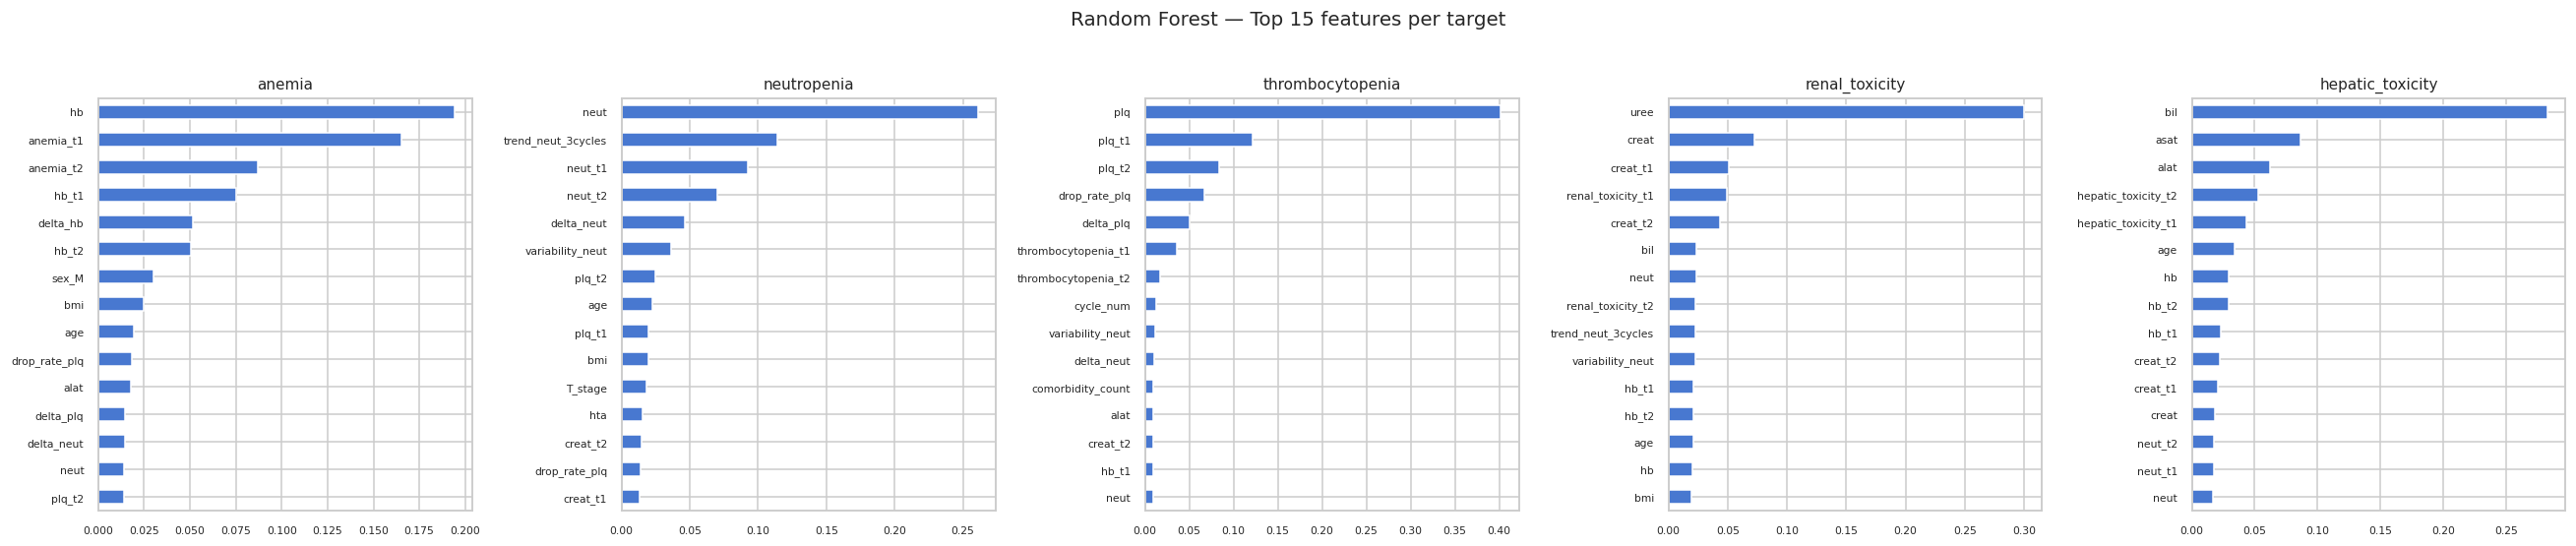

Saved feature_importance_longitudinal.png


In [62]:
feature_names = X_df.columns.tolist()

scaler_fi = StandardScaler()
X_train_s = scaler_fi.fit_transform(X_train)

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
fig.suptitle("Random Forest — Top 15 features per target", fontsize=13, y=1.01)

for ax, target in zip(axes, TARGETS):
    short = target.replace("target_", "")
    y_tr = y_train_all[target].values

    rf = RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    )
    rf.fit(X_train_s, y_tr)

    imp = pd.Series(rf.feature_importances_, index=feature_names).nlargest(15)
    imp[::-1].plot.barh(ax=ax)
    ax.set_title(short, fontsize=10)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig("feature_importance_longitudinal.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved feature_importance_longitudinal.png")